# Primeiras Impressões Dataset

## Explorando o Dataset

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml

In [2]:
mnist = fetch_openml('mnist_784', version=1)

In [3]:
mnist.keys()

dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])

In [4]:
x ,y = mnist["data"].values, mnist["target"].values
y = y.astype(np.uint8)

Label: 2


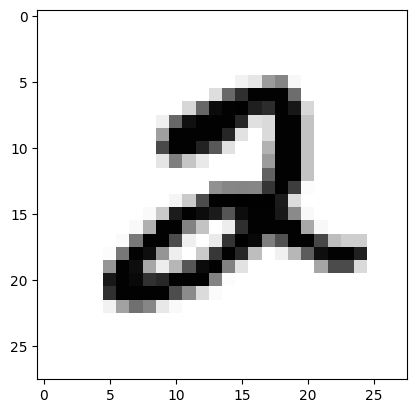

In [5]:
n = 5

plt.imshow(x[n].reshape(28, 28), cmap="binary")
print("Label:", y[n])

## Classificador Binário

O classifcador binário é um modelo treinado para responder apenas "sim" e "não". Utilizando previsões

In [6]:
from sklearn.model_selection import train_test_split

In [7]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

In [8]:
y_train_5 = (y_train == 5)

In [9]:
# Contar os valores de y_train_5 e a distribuição de classes
pd.Series(y_train_5).value_counts()

False    44602
True      4398
Name: count, dtype: int64

In [10]:
from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier()
sgd_clf.fit(x_train, y_train_5)

,"loss loss: {'hinge', 'log_loss', 'modified_huber', 'squared_hinge', 'perceptron', 'squared_error', 'huber', 'epsilon_insensitive', 'squared_epsilon_insensitive'}, default='hinge'The loss function to be used.- 'hinge' gives a linear SVM.- 'log_loss' gives logistic regression, a probabilistic classifier.- 'modified_huber' is another smooth loss that brings tolerance to outliers as well as probability estimates.- 'squared_hinge' is like hinge but is quadratically penalized.- 'perceptron' is the linear loss used by the perceptron algorithm.- The other losses, 'squared_error', 'huber', 'epsilon_insensitive' and 'squared_epsilon_insensitive' are designed for regression but can be useful in classification as well; see :class:`~sklearn.linear_model.SGDRegressor` for a description.More details about the losses formulas can be found in the :ref:`User Guide` and you can find a visualisation of the lossfunctions in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_loss_functions.py`.",'hinge'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only if `loss` is'huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'.For 'huber', determines the threshold at which it becomes lessimportant to get the prediction exactly right.For epsilon-insensitive, any differences between the current predictionand the correct label are ignored if they are less than this threshold.Values must be in the range `[0.0, inf)`.",0.1
,"n_jobs n_jobs: int, default=NoneThe number of CPUs to use to do the OVA (One Versus All, formulti-class problems) computation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


Label: 2
Prediction: [False]


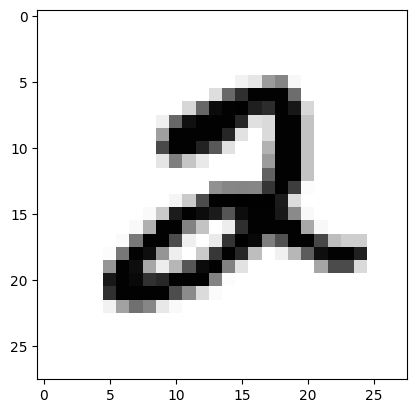

In [11]:
# Visualizando os resutaldos do modelo treinado
n = int(input("Digite um número de 0 a 69999: "))
plt.imshow(x[n].reshape(28, 28), cmap="binary")
print("Label:", y[n])
print("Prediction:", sgd_clf.predict([x[n]]))

### Medindo o desempenho de um modelo, métricas de avaliação;

In [12]:
from sklearn.model_selection import cross_val_score

In [13]:
cross_val_score(sgd_clf, x_train, y_train_5, cv=3, scoring="accuracy")

array([0.96002204, 0.96387681, 0.83199657])

In [14]:
from sklearn.base import BaseEstimator

class Never5Classifier(BaseEstimator):
    def fit(self, x, y=None):
        pass

    def predict(self, x):
        return np.zeros((len(x), 1), dtype=bool)

In [15]:
never_5_clf = Never5Classifier()
cross_val_score(never_5_clf, x_train, y_train_5, cv=3, scoring="accuracy")

array([0.91122811, 0.91024307, 0.90926345])

### Conceito Matemático para Avaliar Desempenho de um modelo

 -- Para medir a qualidade de um modelo de classificação utilizamos a matriz de confusão

Onde .:

TN = True Negative, tudo que o modelo achou que era negativo e de fato era negativo.
FN = False Negative, tudo o que o modelo achar que não é negative e na verdade são negativos.
FP = False Positive, o modelo acha que é positivo, porém não é.
TP = True Positive, o modelo acha que é positivo e de fato é positivo.

• Matriz de Confusão .:
         
        ____F_A_L_S_E________T_R_U_E_____
    F |           TN   |                |
    A |   1            |   FP      3    |
    L |     7     8    |      6         |   → Quantidade Total de Ñ 5
    S |                |                |
    E |    6    3      |   2        1   |
      |________________|________________|
      |           FN   |       TP       |
    T |   5            |    5     5     |
    R |     5     5    |        5       |  → Quantidade Total de 5.
    U |                |     5     5    |
    E |    5    5      |                |
      |________________|________________|

• Precisão do modelo: todos os acertos que fez dividido pelas tentativas realizadas.
  ex: TP / (TP+FP) - Ideal para mercado financeiro.

• Recall: os valores que acertou dividido por todos que haviam para acertar.
  ex: TP/ (TP+FN)

• F1 Score: Média harmônica, penaliza resultados muito desparelho.
  ex: 2x ( Precisão x Recall ) / ∑ ( Precisão + Recall )

In [16]:
# Visualizando a matriz de confusão no python

from sklearn.metrics import confusion_matrix

confusion_matrix(y_train_5, sgd_clf.predict(x_train))

array([[44180,   422],
       [ 1030,  3368]])

In [17]:
from sklearn.metrics import precision_score, recall_score

y_train_pred = sgd_clf.predict(x_train)

print(f"Precision: {precision_score(y_train_5, y_train_pred)*100:.0f} %")
print(f"Recall:    {recall_score(y_train_5, y_train_pred)*100:.0f} %")

Precision: 89 %
Recall:    77 %


In [18]:
from sklearn.metrics import classification_report

classificacao = classification_report(y_train_5, y_train_pred, target_names=["Not 5", "Is 5"])
print(f"Classification Report:\n{classificacao}")

Classification Report:
              precision    recall  f1-score   support

       Not 5       0.98      0.99      0.98     44602
        Is 5       0.89      0.77      0.82      4398

    accuracy                           0.97     49000
   macro avg       0.93      0.88      0.90     49000
weighted avg       0.97      0.97      0.97     49000



## Classificador MultiClasse

In [19]:
sgd_clf.fit(x_train, y_train)

,"loss loss: {'hinge', 'log_loss', 'modified_huber', 'squared_hinge', 'perceptron', 'squared_error', 'huber', 'epsilon_insensitive', 'squared_epsilon_insensitive'}, default='hinge'The loss function to be used.- 'hinge' gives a linear SVM.- 'log_loss' gives logistic regression, a probabilistic classifier.- 'modified_huber' is another smooth loss that brings tolerance to outliers as well as probability estimates.- 'squared_hinge' is like hinge but is quadratically penalized.- 'perceptron' is the linear loss used by the perceptron algorithm.- The other losses, 'squared_error', 'huber', 'epsilon_insensitive' and 'squared_epsilon_insensitive' are designed for regression but can be useful in classification as well; see :class:`~sklearn.linear_model.SGDRegressor` for a description.More details about the losses formulas can be found in the :ref:`User Guide` and you can find a visualisation of the lossfunctions in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_loss_functions.py`.",'hinge'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only if `loss` is'huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'.For 'huber', determines the threshold at which it becomes lessimportant to get the prediction exactly right.For epsilon-insensitive, any differences between the current predictionand the correct label are ignored if they are less than this threshold.Values must be in the range `[0.0, inf)`.",0.1
,"n_jobs n_jobs: int, default=NoneThe number of CPUs to use to do the OVA (One Versus All, formulti-class problems) computation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


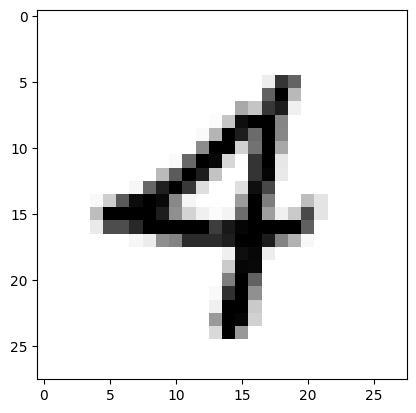

In [23]:
n = int(input("Digite um número de 0 a 69999: "))
digit = x_train[n]
plt.imshow(digit.reshape(28, 28), cmap="binary")

In [24]:
sgd_clf.predict([digit])

array([4], dtype=uint8)

In [25]:
## Cross Validation Predictions - Matriz de Confusão
from sklearn.model_selection import cross_val_predict
y_train_pred = cross_val_predict(sgd_clf, x_train, y_train, cv=3)

In [26]:
conf_mtx = confusion_matrix(y_train, y_train_pred)
print(f"Matriz de Confusão:\n{conf_mtx}")
print(classification_report(y_train, y_train_pred))

Matriz de Confusão:
[[4653    0   22   26   13   27   45    9   43    7]
 [   2 5333   39   10    6   19    9   12   73   10]
 [  51  165 3952  192   61   43   96   96  179   22]
 [  33   31  181 4037   21  248   26   78  258   52]
 [  12   23   37   14 4457   15   52   42   70  166]
 [  65   31   48  170   85 3529  143   43  220   64]
 [  44   40   41    8   31   87 4475    7   54    1]
 [  16   38   46   26   73    9    4 4649   48  136]
 [  54  167   70  163   59  290   39   36 3875   80]
 [  22   31   23   89  286   72    4  398  244 3699]]
              precision    recall  f1-score   support

           0       0.94      0.96      0.95      4845
           1       0.91      0.97      0.94      5513
           2       0.89      0.81      0.85      4857
           3       0.85      0.81      0.83      4965
           4       0.88      0.91      0.89      4888
           5       0.81      0.80      0.81      4398
           6       0.91      0.93      0.92      4788
           7    

<Axes: >

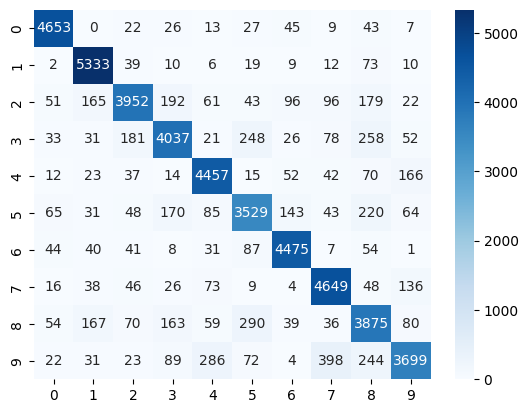

In [27]:
sns.heatmap(conf_mtx, annot=True, fmt="d", cmap="Blues", xticklabels=np.unique(y_train), yticklabels=np.unique(y_train))

<Axes: >

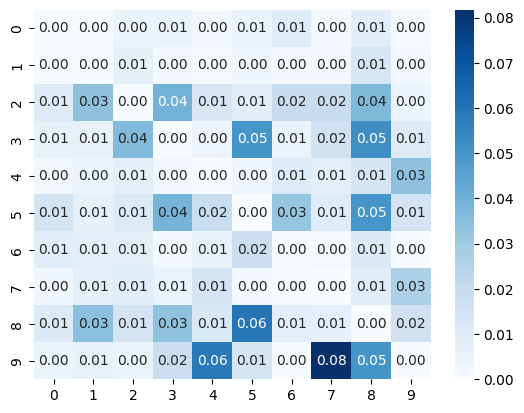

In [28]:
row_sums = conf_mtx.sum(axis=1, keepdims=True)
normalized_conf_mtx = conf_mtx / row_sums
np.fill_diagonal(normalized_conf_mtx, 0)
sns.heatmap(normalized_conf_mtx, annot=True, fmt=".2f", cmap="Blues", xticklabels=np.unique(y_train), yticklabels=np.unique(y_train))